In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import sys
import os

sys.path.append(os.path.abspath("../"))

from src.preprocessing import get_preprocessor

df = pd.read_csv("../data/train.csv")
df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)
X = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

categorical_cols_with_na = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual",
    "GarageCond", "PoolQC", "Fence", "MiscFeature"
]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)
preprocessor = get_preprocessor(categorical_cols_with_na)

model = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    n_jobs=-1,
    early_stopping_rounds=50,
    random_state=42,
    colsample_bytree=0.7,
    max_depth=5,
    subsample=0.8
)
# {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8}
X_train_prepped = preprocessor.fit_transform(X_train)
X_valid_prepped = preprocessor.transform(X_valid)

model.fit(
    X_train_prepped, y_train,
    eval_set=[(X_valid_prepped, y_valid)],
    verbose=False
)

full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

preds = full_pipeline.predict(X_valid)
score = mean_absolute_error(y_valid, preds)
print(f"XGBoost (with Early Stopping) MAE: ${score:,.2f}")

XGBoost (with Early Stopping) MAE: $14,170.44


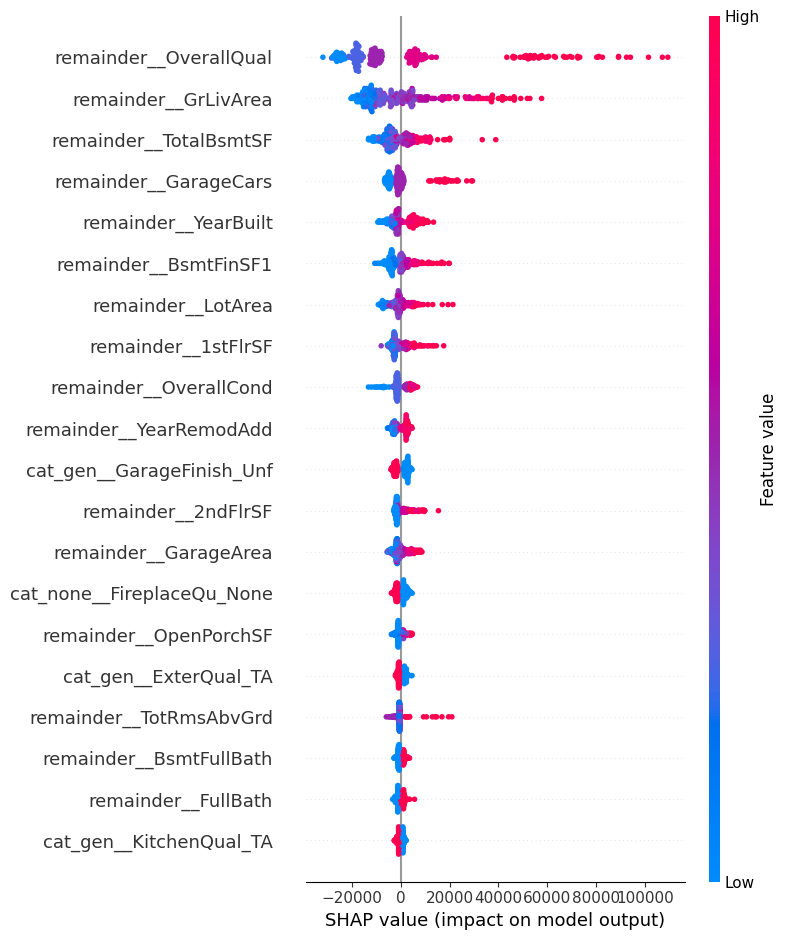

In [3]:
import shap
import matplotlib.pyplot as plt

# 1. Extract the feature names (the 1% move)
# This gets the names like 'Neighborhood_NoRidge', 'GrLivArea', etc.
feature_names = preprocessor.get_feature_names_out()

# 2. Initialize the Explainer
# SHAP has a specific 'TreeExplainer' optimized for XGBoost/Random Forest
explainer = shap.TreeExplainer(model)

# 3. Calculate SHAP values for your validation set
# We use the X_valid_prepped we created for early stopping
shap_values = explainer.shap_values(X_valid_prepped)

# 4. Visualize the Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_valid_prepped, feature_names=feature_names)

In [4]:
from sklearn.model_selection import GridSearchCV

df = df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index)

X = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=42)

categorical_cols_with_na = [
    "Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", 
    "BsmtFinType2", "FireplaceQu", "GarageType", "GarageFinish", 
    "GarageQual", "GarageCond", "PoolQC", "Fence", "MiscFeature"
]
preprocessor = get_preprocessor(categorical_cols_with_na)

search_model = XGBRegressor(n_jobs=-1, random_state=42)
search_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", search_model)])

param_grid = {
    'model__max_depth': [3, 5, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8]
}

print("Starting Grid Search...")
grid_search = GridSearchCV(search_pipeline, param_grid, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_params = {k.replace('model__', ''): v for k, v in grid_search.best_params_.items()}

final_model = XGBRegressor(
    **best_params,
    n_estimators=5000,   
    early_stopping_rounds=50,
    random_state=42,
    n_jobs=-1
)

X_train_prepped = preprocessor.fit_transform(X_train)
X_valid_prepped = preprocessor.transform(X_valid)

final_model.fit(
    X_train_prepped, y_train,
    eval_set=[(X_valid_prepped, y_valid)],
    verbose=False
)

full_pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", final_model)])
preds = full_pipeline.predict(X_valid)

print(f"Best Params Found: {best_params}")
print(f"Final Tuned XGBoost MAE: ${mean_absolute_error(y_valid, preds):,.2f}")

Starting Grid Search...
Best Params Found: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.8}
Final Tuned XGBoost MAE: $14,212.68


In [5]:
test_data = pd.read_csv("../data/test.csv")
test_preds = full_pipeline.predict(test_data)

output = pd.DataFrame({
    'Id': test_data.Id,
    'SalePrice': test_preds
})

output.to_csv('../data/submission.csv', index=False)
print("Submission file successfully saved!")

Submission file successfully saved!


In [6]:
import joblib

joblib.dump(full_pipeline, '../models/house_price_model.pkl')

['../models/house_price_model.pkl']